In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 67.0 MB/s eta 0:00:00


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/라즈베리파이/Yolo/dataset.zip"
extract_path = "/content/my_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ 압축 해제 완료! (폴더 구조 그대로 유지됨)")

✅ 압축 해제 완료! (폴더 구조 그대로 유지됨)


In [4]:
import os
print(len(os.listdir("/content/my_data/train/images")))
print(len(os.listdir("/content/my_data/valid/images")))
print(len(os.listdir("/content/my_data/test/images")))



6572
611
508


In [5]:
from ultralytics import YOLO
import os, shutil
data_path = os.path.abspath('my_data/data.yaml')
model = YOLO('yolo11n.pt')
print(f"🚀 학습 시작! (Early Stopping 적용됨)")

results = model.train(
    data=data_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=10,

    # 기본 augment 제한
    fliplr=0.0,
    flipud=0.0,

    # 🔥 밝기·채도 문제 정조준
    hsv_h=0.10,      # 색조 변화 더 넓힘
    hsv_s=0.9,       # 채도 변화 max
    hsv_v=0.65,      # 밝음/어두움 완전 범위 대응

    # 🔧 구조는 유지 (over-distortion 방지)
    degrees=5,
    translate=0.1,
    scale=0.55,
    shear=0.10,

    mosaic=0.0,
    mixup=0.0,
    erasing=0.0
)



# YOLO 학습 코드 이후에 실행!
best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')
target_path = '/content/drive/MyDrive/라즈베리파이/Yolo/best_strong4 .pt'

# 폴더 없으면 자동 생성
os.makedirs(os.path.dirname(target_path), exist_ok=True)

if os.path.exists(best_model_path):
    shutil.copy(best_model_path, target_path)
    print("🎉 모델 저장 완료 →", target_path)
else:
    print("⚠️ best.pt 파일을 찾을 수 없습니다:", best_model_path)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 학습 시작! (Early Stopping 적용됨)
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/my_data/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.1, hsv_s=0.9, hsv_v=0.65, img

In [6]:
model.val(data="/content/my_data/data.yaml", split='test')

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 738.3±219.5 MB/s, size: 21.3 KB)
val: Scanning /content/my_data/test/labels... 508 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 508/508 1.6Kit/s 0.3s
val: New cache created: /content/my_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 11.1it/s 2.9s
                   all        508        508      0.997          1      0.995      0.832
                  left         51         51      0.997          1      0.995      0.783
                 right         60         60      0.998          1      0.995      0.835
                  slow         59         59      0.997          1      0.995      0.781
                  stop         55         55      0.999          1     

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b7e0131b380>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

# 분류기 학습

In [ ]:
import os
import cv2
from tqdm import tqdm

base_dir = "/content/my_data"   # train/valid/test 포함된 루트
splits = ["train", "valid", "test"]

# YOLO 클래스 이름 (원래 전체 순서)
all_class_names = [
    "left",
    "right",
    "slow",
    "stop",
    "straight",
    "traffic_green",
    "traffic_red",
    "traffic_yellow",
    "trumpet"
]

# 우리가 필요한 클래스만 선택
target_classes = {"left", "right", "straight"}

output_root = "/content/classifier_data2"
os.makedirs(output_root, exist_ok=True)


def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int((xc - w/2) * W)
    y1 = int((yc - h/2) * H)
    x2 = int((xc + w/2) * W)
    y2 = int((yc + h/2) * H)
    return max(0, x1), max(0, y1), min(W-1, x2), min(H-1, y2)


for split in splits:
    img_dir = f"{base_dir}/{split}/images"
    lbl_dir = f"{base_dir}/{split}/labels"

    for img_file in tqdm(os.listdir(img_dir), desc=f"{split}"):
        if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(img_dir, img_file)
        lbl_path = os.path.join(lbl_dir, img_file.rsplit(".", 1)[0] + ".txt")

        if not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)
        H, W = img.shape[:2]

        with open(lbl_path, "r") as f:
            line = f.readline().strip()

        if not line:
            continue

        cls, xc, yc, w, h = line.split()
        cls = int(cls)
        xc, yc, w, h = map(float, (xc, yc, w, h))

        # 🔥 현재 클래스가 left/right/straight 인지 확인
        cls_name = all_class_names[cls]
        if cls_name not in target_classes:
            continue   # → 다른 클래스는 무시

        # YOLO → xyxy
        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)

        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (224, 224))

        # output 폴더
        class_folder = f"{output_root}/{cls_name}"
        os.makedirs(class_folder, exist_ok=True)

        out_name = f"{split}_{img_file.rsplit('.',1)[0]}.jpg"
        out_path = f"{class_folder}/{out_name}"

        cv2.imwrite(out_path, crop)

print("🔥 완료! /content/classifier_data 에 left/right/straight만 생성됨.")


test: 100%|██████████| 310/310 [00:00<00:00, 710.07it/s]

🔥 완료! /content/classifier_data 에 left/right/straight만 생성됨.


클래스: ['left', 'right', 'straight']


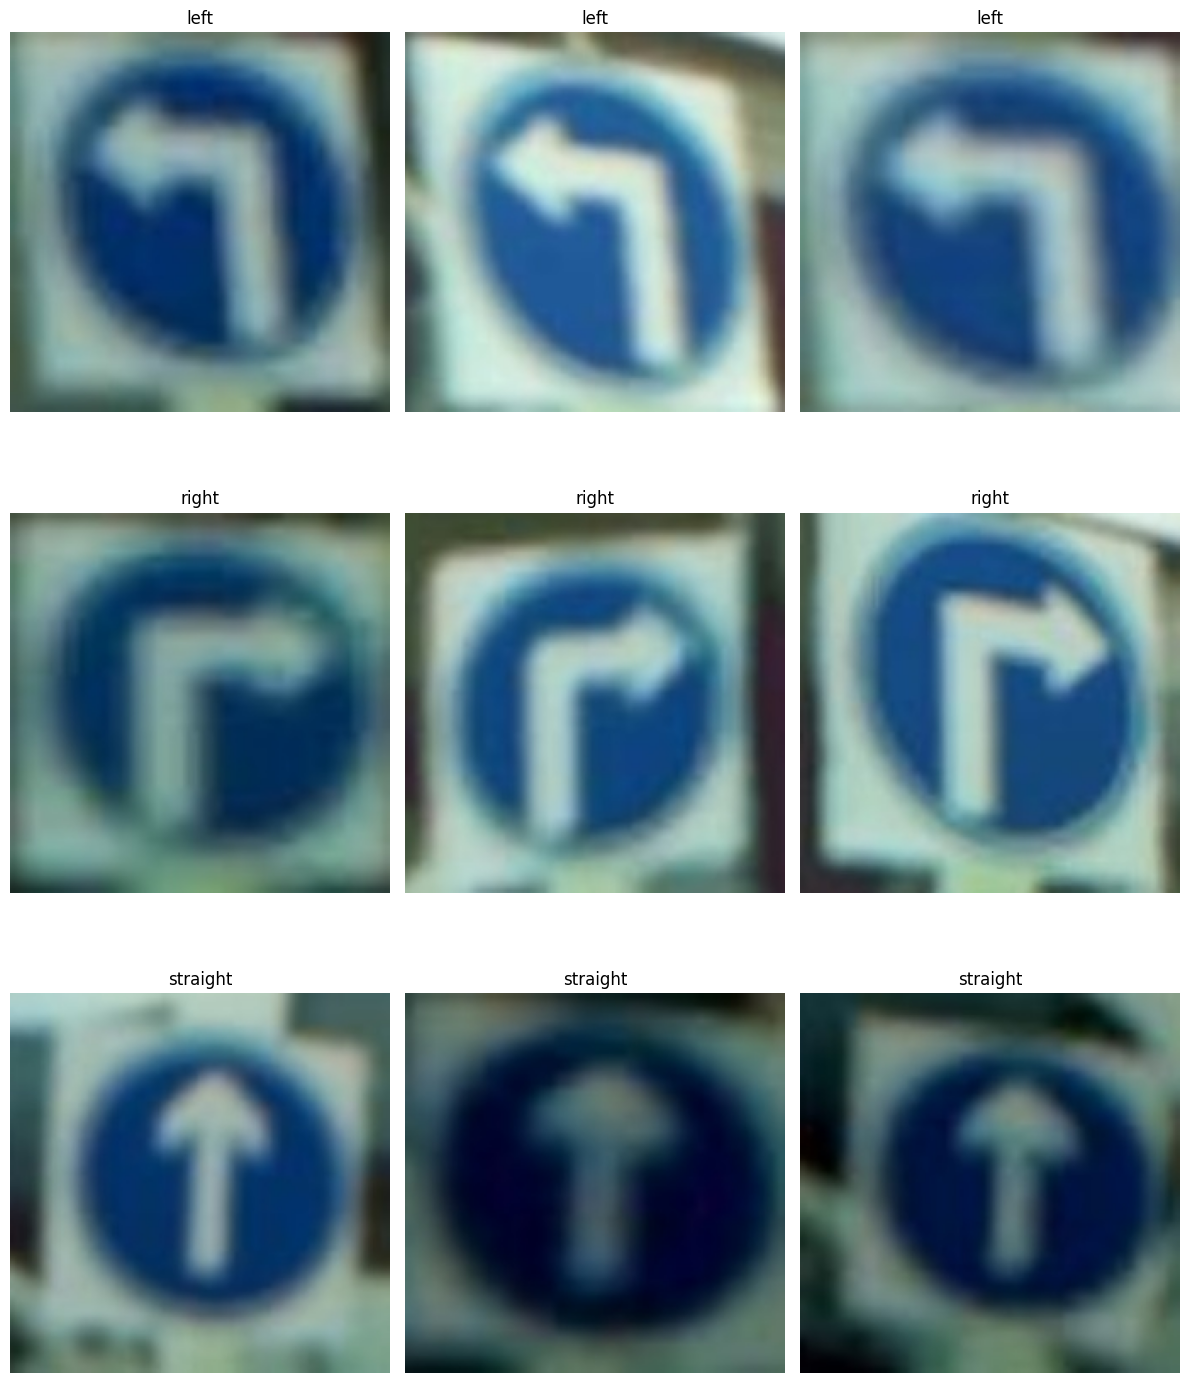

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

root = "/content/classifier_data2"

# 클래스 폴더 가져오기
classes = sorted(os.listdir(root))
print("클래스:", classes)

# 클래스별로 3장씩 랜덤 표시
num_samples = 3

plt.figure(figsize=(12, 15))

idx = 1
for cls in classes:
    class_dir = os.path.join(root, cls)
    images = os.listdir(class_dir)

    # 이미지가 너무 적으면 자동 skip
    if len(images) == 0:
        continue

    # 랜덤 이미지 선택
    samples = random.sample(images, min(num_samples, len(images)))

    for s in samples:
        img_path = os.path.join(class_dir, s)
        img = Image.open(img_path)

        plt.subplot(len(classes), num_samples, idx)
        plt.imshow(img)
        plt.axis("off")
        plt.title(cls)
        idx += 1

plt.tight_layout()
plt.show()


In [ ]:
dir = "/content/classifier_data2"
for c in os.listdir(dir):
  path = os.path.join(dir,c)
  print(f"{c} : {len(os.listdir(path))}")

straight : 542
right : 486
left : 511


In [ ]:
import tensorflow as tf
import os

DATA_DIR = "/content/classifier_data2"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# =====================================================
# 1. Train/Valid/Test 자동 분리 (주의: Keras split 방식)
# =====================================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

valtest_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# val/test 15%씩 분리
val_batches = tf.data.experimental.cardinality(valtest_ds)
val_ds = valtest_ds.take(val_batches // 2)
test_ds = valtest_ds.skip(val_batches // 2)

class_names = train_ds.class_names
num_classes = len(class_names)
print("클래스:", class_names)
print(f"Train: {len(train_ds)*BATCH_SIZE}, Val: {len(val_ds)*BATCH_SIZE}, Test: {len(test_ds)*BATCH_SIZE}")

# =====================================================
# 2. Prefetch (성능 최적화)
# =====================================================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# =====================================================
# 3. TinyCNN 200K (그대로 사용)
# =====================================================
def TinyCNN_200K(input_shape=(224, 224, 3), num_classes=9):
    inputs = tf.keras.Input(shape=input_shape)

    # ------------------------
    # 학습 시에만 작동하는 증강
    # ------------------------
    data_aug = tf.keras.Sequential([
        tf.keras.layers.RandomBrightness(0.25),
        tf.keras.layers.RandomContrast(0.30),
        tf.keras.layers.RandomTranslation(0.10, 0.10),
        tf.keras.layers.RandomZoom(0.20),
        tf.keras.layers.GaussianNoise(0.03),
        tf.keras.layers.RandomRotation(0.03),  # 약 3° 정도만
    ])

    x = data_aug(inputs)   # ★여기가 포인트★
    x = tf.keras.layers.Rescaling(1./255)(x)

    # Block 1
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = TinyCNN_200K(input_shape=(224, 224, 3), num_classes=num_classes)
model.summary()
print("\n총 파라미터 수:", model.count_params())

# =====================================================
# 4. Compile
# =====================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =====================================================
# 5. Callbacks (EarlyStopping + ReduceLROnPlateau)
# =====================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6
    )
]

# =====================================================
# 6. Train (epochs 늘림)
# =====================================================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=callbacks
)

# =====================================================
# 7. Test 평가
# =====================================================
test_loss, test_acc = model.evaluate(test_ds)
print("\n⭐⭐ Test Accuracy:", test_acc, "⭐⭐")


Found 1539 files belonging to 3 classes.
Using 1078 files for training.
Found 1539 files belonging to 3 classes.
Using 461 files for validation.
클래스: ['left', 'right', 'straight']
Train: 1088, Val: 224, Test: 256


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_13 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,907 (1.16 MB)

 Trainable params: 303,907 (1.16 MB)

 Non-trainable params: 0 (0.00 B)


총 파라미터 수: 303907
Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.3503 - loss: 1.1018 - val_accuracy: 0.3170 - val_loss: 1.0996 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3376 - loss: 1.0981 - val_accuracy: 0.2902 - val_loss: 1.1015 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3322 - loss: 1.0990 - val_accuracy: 0.3304 - val_loss: 1.0983 - learning_rate: 0.0010
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3252 - loss: 1.0981 - val_accuracy: 0.2946 - val_loss: 1.0991 - learning_rate: 0.0010
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3236 - loss: 1.0982 - val_accuracy: 0.2768 - val_loss: 1.1012 - learning_rate: 0.0010
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3324 - loss: 1.0982 - val_accuracy: 0.2857 - val_loss: 1.0989 - learning_rate: 0.0010
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.3523

In [ ]:
# Keras H5 저장
model.save("/content/assistance.keras")

# # SavedModel 포맷 저장 (TFLite 변환에 더 적합)
# model.save("/content/tinycnn200k_savedmodel")


<Figure size 1000x800 with 0 Axes>

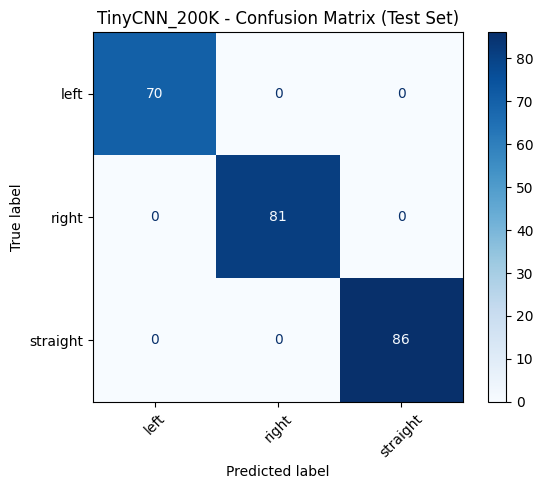

Confusion Matrix:
[[70  0  0]
 [ 0 81  0]
 [ 0  0 86]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ================================
# Test 데이터 prediction 수행
# ================================
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds_cls = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_cls)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ================================
# Confusion Matrix 계산
# ================================
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# ================================
# 시각화
# ================================
plt.figure(figsize=(10, 8))
disp.plot(cmap="Blues", values_format="d")
plt.title("TinyCNN_200K - Confusion Matrix (Test Set)")
plt.xticks(rotation=45)
plt.show()

print("Confusion Matrix:")
print(cm)


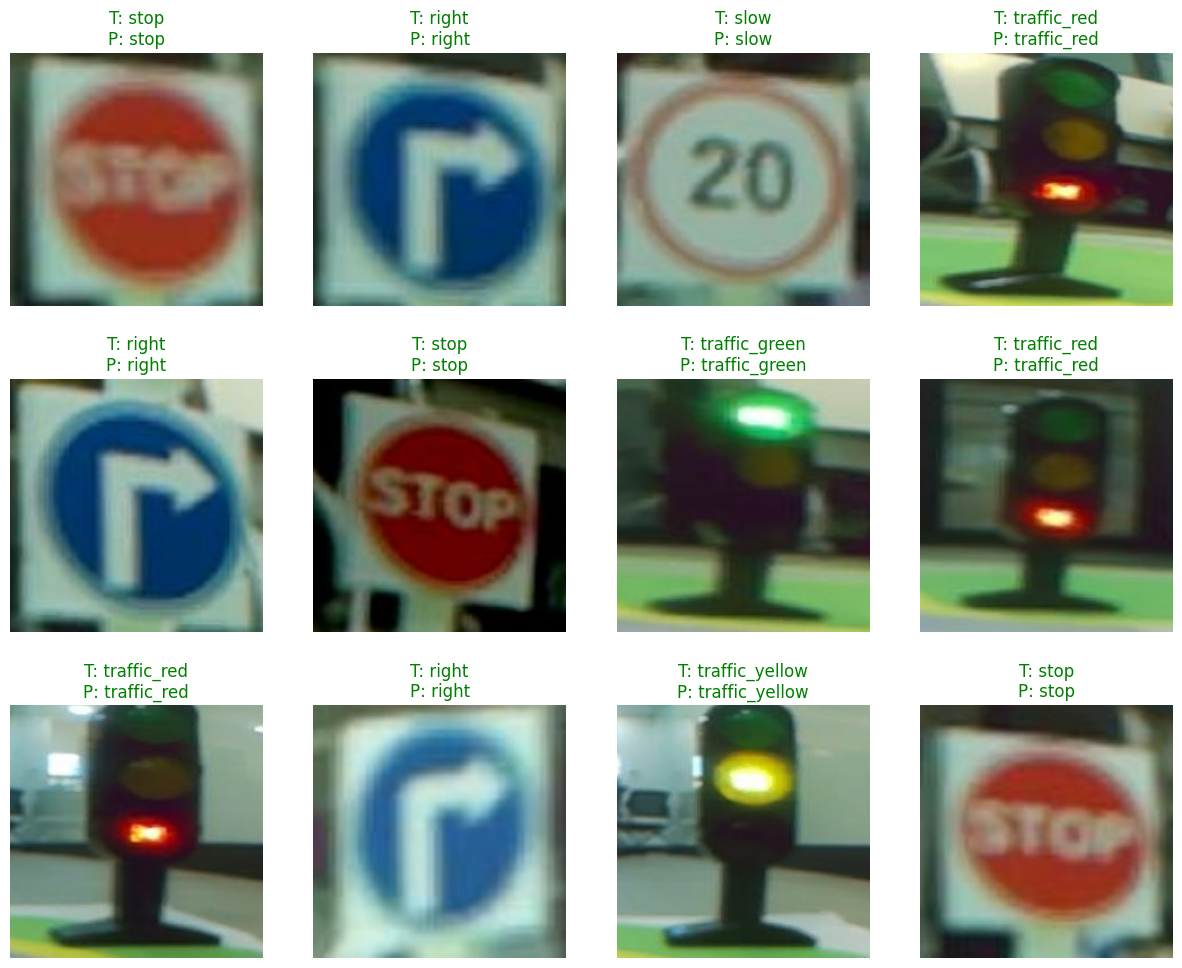

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# TinyCNN 모델로 예측 확인
# -------------------------

def show_test_samples(model, dataset, class_names, num_images=12):
    """
    test_ds에서 이미지 n장을 시각화 + 분류 결과 출력
    """
    plt.figure(figsize=(15, 12))
    count = 0

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_cls = np.argmax(preds, axis=1)

        for i in range(len(images)):
            if count >= num_images:
                plt.show()
                return

            plt.subplot(3, 4, count + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.axis("off")

            true_label = class_names[int(labels[i])]
            pred_label = class_names[pred_cls[i]]
            color = "green" if true_label == pred_label else "red"

            plt.title(f"T: {true_label}\nP: {pred_label}", color=color)

            count += 1

    plt.show()

# 실행
show_test_samples(model, test_ds, class_names, num_images=12)
